In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [ ]:
file_path = '/content/drive/MyDrive/오늘의집_문장_라벨링.csv'
df = pd.read_csv(file_path)
df.head()

,label,post_id,sentence_id,sentence,ai_label
0,NaN,20531,0,도면 <의뢰인 요청사항> Story 1.,5
1,NaN,20531,1,기존 거실 발코니 확장.,5
2,NaN,20531,2,Story 2.,5
3,NaN,20531,3,안방 폴딩도어 계획 및 발코니 좌식 평상 제작.,5
4,NaN,20531,4,Story 3.,5


In [ ]:
# ai_label 컬럼 제거
df2 = df.drop(
    columns=["ai_label"]
)

# 확인
df2.head()

,label,post_id,sentence_id,sentence
0,NaN,20531,0,도면 <의뢰인 요청사항> Story 1.
1,NaN,20531,1,기존 거실 발코니 확장.
2,NaN,20531,2,Story 2.
3,NaN,20531,3,안방 폴딩도어 계획 및 발코니 좌식 평상 제작.
4,NaN,20531,4,Story 3.


In [ ]:
# 랜덤 2만개 추출
df_sample = (

df

.sample(
    n=20000,
    random_state=42
)

.reset_index(
    drop=True
)

)

# 확인
print(
df_sample.shape
)

display(
df_sample.head()
)

(20000, 5)


,label,post_id,sentence_id,sentence,ai_label
0,NaN,137909,253,슬라이딩 수납장 안쪽으로 콘센트를 연결해요.,5
1,NaN,93179,73,안방욕실 Before 안방욕실 After 기존엔 양변기와 세면대뿐이었던 협소한 안방...,5
2,NaN,158566,76,커피캡슐도 호환되는데 캡슐 사용 시에는 크레마가 좀 적게 만들어지더라고요.,5
3,NaN,180383,70,사계절 내내 변하는 풍경이 주는 작은 위로 덕분에 집이라는 공간은 저에게 언제나 특...,5
4,NaN,180514,164,감사합니다.,5


In [ ]:
!pip install transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split

post_ids = (
df_sample["post_id"]
.unique()
)

train_posts, valid_posts = train_test_split(

post_ids,

test_size=0.2,

random_state=42

)

train_df = (
df_sample[
df_sample["post_id"]
.isin(
train_posts
)
]
)

valid_df = (
df_sample[
df_sample["post_id"]
.isin(
valid_posts
)
]
)

print(
train_df.shape
)

print(
valid_df.shape
)

(15975, 5)
(4025, 5)


In [ ]:
import torch

class SpaceDataset(
torch.utils.data.Dataset
):

    def __init__(

        self,

        texts,

        labels,

        tokenizer,

        max_length=128

    ):

        self.encodings = tokenizer(

            texts,

            truncation=True,

            padding=True,

            max_length=max_length

        )

        self.labels = labels


    def __getitem__(

        self,

        idx

    ):

        item = {

            k:
            torch.tensor(v[idx])

            for k,v

            in self.encodings.items()

        }

        item["labels"] = (
            torch.tensor(
                self.labels[idx],
                dtype=torch.float
            )
        )

        return item


    def __len__(

        self

    ):

        return len(
            self.labels
        )

In [ ]:
from transformers import (

AutoTokenizer,

AutoModelForSequenceClassification

)

model_name = (
"monologg/koelectra-base-v3-discriminator"
)

tokenizer = (

AutoTokenizer

.from_pretrained(
model_name
)

)

model = (

AutoModelForSequenceClassification

.from_pretrained(

model_name,

num_labels=5,

problem_type=
"multi_label_classification"

)

)

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/452M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/452M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

In [ ]:
label_order = [
"0",
"1",
"2",
"4",
"5"
]

def make_label_vector(x):

    labels = (
        str(x)
        .replace(" ", "")
        .split(",")
    )

    return [

        int(
            l in labels
        )

        for l

        in label_order

    ]


train_df["labels"] = (

train_df["ai_label"]

.astype(str)

.apply(
make_label_vector
)

)

valid_df["labels"] = (

valid_df["ai_label"]

.astype(str)

.apply(
make_label_vector
)

)

/tmp/ipykernel_805/3559553017.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["labels"] = (
/tmp/ipykernel_805/3559553017.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df["labels"] = (


In [ ]:
train_dataset = (

SpaceDataset(

train_df["sentence"].tolist(),

train_df["labels"].tolist(),

tokenizer

)

)

valid_dataset = (

SpaceDataset(

valid_df["sentence"].tolist(),

valid_df["labels"].tolist(),

tokenizer

)

)

In [ ]:
from sklearn.metrics import (
    f1_score
)

import numpy as np


def compute_metrics(pred):

    logits = pred.predictions

    labels = pred.label_ids


    probs = (

        1

        /

        (

            1

            +

            np.exp(
                -logits
            )

        )

    )


    preds = (

        probs

        >

        0.5

    ).astype(int)


    return {

        "f1_macro":

        f1_score(

            labels,

            preds,

            average="macro",

            zero_division=0

        ),

        "f1_micro":

        f1_score(

            labels,

            preds,

            average="micro",

            zero_division=0

        )

    }

In [ ]:
from transformers import (
    TrainingArguments
)

args = (

TrainingArguments(

output_dir=
"./koelectra",

eval_strategy=
"epoch",

save_strategy=
"epoch",

learning_rate=
2e-5,

per_device_train_batch_size=
16,

per_device_eval_batch_size=
16,

num_train_epochs=
3,

weight_decay=
0.01,

load_best_model_at_end=
True,

metric_for_best_model=
"f1_macro",

greater_is_better=
True,

report_to=
"none",

fp16=
True

)

)

In [ ]:
per_device_train_batch_size=8

In [ ]:
from transformers import (
Trainer
)

trainer = (

Trainer(

model=model,

args=args,

train_dataset=
train_dataset,

eval_dataset=
valid_dataset,

compute_metrics=
compute_metrics

)

)

In [ ]:
from sklearn.metrics import (
    f1_score
)

import numpy as np


def compute_metrics(pred):

    logits = pred.predictions

    labels = pred.label_ids


    probs = (

        1

        /

        (

            1

            +

            np.exp(
                -logits
            )

        )

    )


    preds = (

        probs

        >

        0.5

    ).astype(int)


    return {

        "f1_macro":

        f1_score(

            labels,

            preds,

            average="macro",

            zero_division=0

        ),

        "f1_micro":

        f1_score(

            labels,

            preds,

            average="micro",

            zero_division=0

        )

    }

In [ ]:
from transformers import (
    TrainingArguments
)

args = (

TrainingArguments(

output_dir=
"./koelectra",

eval_strategy=
"epoch",

save_strategy=
"epoch",

learning_rate=
2e-5,

per_device_train_batch_size=
16,

per_device_eval_batch_size=
16,

num_train_epochs=
3,

weight_decay=
0.01,

load_best_model_at_end=
True,

metric_for_best_model=
"f1_macro",

greater_is_better=
True,

report_to=
"none",

fp16=
True

)

)

In [ ]:
from transformers import (
Trainer
)

trainer = (

Trainer(

model=model,

args=args,

train_dataset=
train_dataset,

eval_dataset=
valid_dataset,

compute_metrics=
compute_metrics

)

)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro
1,0.183467,0.134937,0.190146,0.906087
2,0.099816,0.089575,0.198036,0.928895
3,0.070980,0.078685,0.316145,0.937292


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=2997, training_loss=0.10674936818328745, metrics={'train_runtime': 440.1149, 'train_samples_per_second': 108.892, 'train_steps_per_second': 6.81, 'total_flos': 3152484244396800.0, 'train_loss': 0.10674936818328745, 'epoch': 3.0})

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import pandas as pd
import torch

model_list = {
    "klue_bert": "klue/bert-base",
    "klue_roberta_small": "klue/roberta-small",
    "kcelectra": "beomi/KcELECTRA-base-v2022"
}

results = []

for model_key, model_name in model_list.items():

    print("\n" + "="*80)
    print(f"모델 학습 시작: {model_key}")
    print(model_name)
    print("="*80)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = SpaceDataset(
        train_df["sentence"].tolist(),
        train_df["labels"].tolist(),
        tokenizer
    )

    valid_dataset = SpaceDataset(
        valid_df["sentence"].tolist(),
        valid_df["labels"].tolist(),
        tokenizer
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=5,
        problem_type="multi_label_classification"
    )

    args = TrainingArguments(
        output_dir=f"./{model_key}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        report_to="none",
        fp16=torch.cuda.is_available()
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    eval_result = trainer.evaluate()

    eval_result["model_key"] = model_key
    eval_result["model_name"] = model_name

    results.append(eval_result)

    trainer.save_model(f"./best_{model_key}")
    tokenizer.save_pretrained(f"./best_{model_key}")

    print(f"{model_key} 저장 완료")


모델 학습 시작: klue_bert
klue/bert-base


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro
1,0.119800,0.050946,0.797889,0.959572
2,0.042103,0.040111,0.867175,0.972281
3,0.023534,0.041744,0.872103,0.972536


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

kcelectra 저장 완료


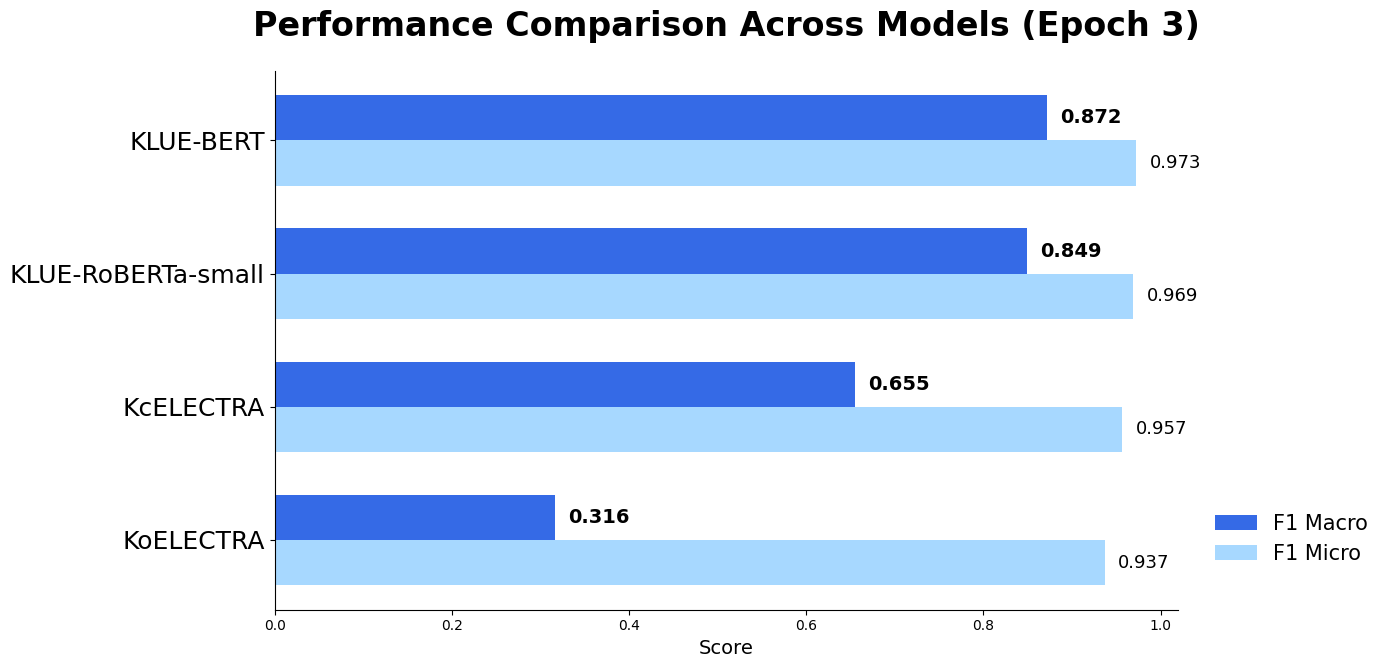

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"

result_df = pd.DataFrame({

"Model":[
"KLUE-BERT",
"KLUE-RoBERTa-small",
"KcELECTRA",
"KoELECTRA"
],

"F1 Macro":[
0.872103,
0.849182,
0.655215,
0.316145
],

"F1 Micro":[
0.972536,
0.969072,
0.956663,
0.937292
]

})

result_df = (
result_df
.sort_values(
"F1 Macro",
ascending=False
)
)

fig, ax = plt.subplots(
figsize=(13,7)
)

width = 0.34
y = range(len(result_df))


macro_color = "#356AE6"
micro_color = "#A7D8FF"


ax.barh(

[i-width/2 for i in y],

result_df["F1 Macro"],

height=width,

color=macro_color,

label="F1 Macro"

)


ax.barh(

[i+width/2 for i in y],

result_df["F1 Micro"],

height=width,

color=micro_color,

label="F1 Micro"

)


ax.set_yticks(y)

ax.set_yticklabels(
result_df["Model"],
fontsize=18
)

ax.invert_yaxis()


ax.set_xlim(
0,
1.02
)

ax.set_xlabel(
"Score",
fontsize=14
)

ax.set_title(
"Performance Comparison Across Models (Epoch 3)",
fontsize=24,
fontweight="bold",
pad=25
)


# 값 표시
for i,v in enumerate(result_df["F1 Macro"]):

    ax.text(

        v+0.015,

        i-width/2,

        f"{v:.3f}",

        fontsize=14,

        fontweight="bold",

        va="center"

    )


for i,v in enumerate(result_df["F1 Micro"]):

    ax.text(

        v+0.015,

        i+width/2,

        f"{v:.3f}",

        fontsize=13,

        va="center"

    )


# 범례를 그래프 밖으로 이동
ax.legend(

loc="lower left",

bbox_to_anchor=(1.02,0.05),

frameon=False,

fontsize=15

)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# 오른쪽 여백 확보
plt.subplots_adjust(
right=0.82
)

plt.show()

In [ ]:
model_name="klue/bert-base"
trainer.train()

from sklearn.metrics import (
classification_report
)

import numpy as np
import pandas as pd


pred = trainer.predict(
valid_dataset
)


prob = (
1
/
(
1
+
np.exp(
-pred.predictions
)
)
)


preds = (
prob>0.5
).astype(int)


report = classification_report(

pred.label_ids,

preds,

target_names=[

"0",
"1",
"2",
"4",
"5"

],

output_dict=True,

zero_division=0

)


result = (

pd.DataFrame(
report
)

.T

)


display(

result[
[
"precision",
"recall",
"f1-score",
"support"
]
]

)

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro
1,0.049396,0.047890,0.824830,0.969275
2,0.033361,0.045578,0.850099,0.971912
3,0.022398,0.049118,0.847085,0.969321


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

,precision,recall,f1-score,support
0,0.750000,0.913043,0.823529,92.0
1,0.847222,0.835616,0.841379,146.0
2,0.805556,0.591837,0.682353,49.0
4,0.963415,0.868132,0.913295,91.0
5,0.985746,0.986016,0.985881,3647.0
micro avg,0.972153,0.971429,0.971791,4025.0
macro avg,0.870388,0.838929,0.849287,4025.0
weighted avg,0.972634,0.971429,0.971592,4025.0
samples avg,0.971180,0.971429,0.971263,4025.0
